**Image Classification using CNN**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# --- 1. LOAD AND PREPROCESS DATA ---
# Load the full CIFAR-10 dataset
(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values (0-255 -> 0-1)
x_train_full = x_train_full.astype('float32') / 255.0
x_test_full = x_test_full.astype('float32') / 255.0

# Define the specific classes we want (Index from CIFAR-10 documentation)
# 1 = Automobile, 8 = Ship, 9 = Truck
target_classes = [1, 8, 9]

In [ ]:
def filter_data(x, y, classes):
    keep_mask = np.isin(y, classes).flatten()
    x_filtered = x[keep_mask]
    y_filtered = y[keep_mask]

    label_map = {1: 0, 8: 1, 9: 2}

    y_filtered = np.array([label_map[label[0]] for label in y_filtered])

    return x_filtered, y_filtered

In [ ]:
# Apply the filter
x_train, y_train = filter_data(x_train_full, y_train_full, target_classes)
x_test, y_test = filter_data(x_test_full, y_test_full, target_classes)

print(f"Training data shape: {x_train.shape}")
print(f"We now have {len(x_train)} vehicle images only.")

Training data shape: (15000, 32, 32, 3)
We now have 15000 vehicle images only.


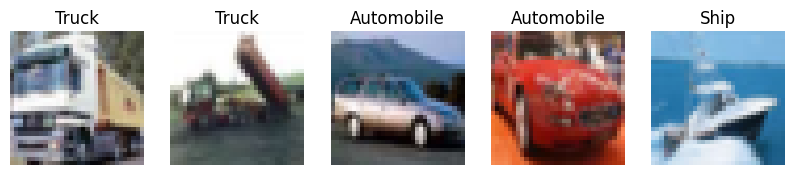

In [ ]:
class_names_new = ['Automobile', 'Ship', 'Truck']

plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names_new[y_train[i]])
    plt.axis('off')
plt.show()

In [ ]:
# --- 3. BUILD THE CNN ---
model = models.Sequential([
    # Conv Block 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    # Conv Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Conv Block 3
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Classifier Head
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax') # Output is 3 because we only have 3 classes now
])

In [ ]:
# --- 4. COMPILE AND TRAIN ---
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', # 'sparse' because our labels are integers (0,1,2)
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10,
                    validation_data=(x_test, y_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step - accuracy: 0.5869 - loss: 0.8538 - val_accuracy: 0.7773 - val_loss: 0.5391
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step - accuracy: 0.7935 - loss: 0.5142 - val_accuracy: 0.8293 - val_loss: 0.4354
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - accuracy: 0.8355 - loss: 0.4192 - val_accuracy: 0.8563 - val_loss: 0.3758
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.8720 - loss: 0.3317 - val_accuracy: 0.8803 - val_loss: 0.3357
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - accuracy: 0.8961 - loss: 0.2788 - val_accuracy: 0.8700 - val_loss: 0.3533
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step - accuracy: 0.9072 - loss: 0.2561 - val_accuracy: 0.8727 - val_loss: 0.3588
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - accuracy: 0.9170 - loss: 0.2218 - val_accuracy: 0.8840 - val_loss: 0.3371
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - accuracy: 0.9302 - loss: 0.1875 - 

In [ ]:
# --- 5. EVALUATE ---
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest accuracy on vehicles: {test_acc*100:.2f}%")

94/94 - 2s - 24ms/step - accuracy: 0.8930 - loss: 0.3139

Test accuracy on vehicles: 89.30%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step


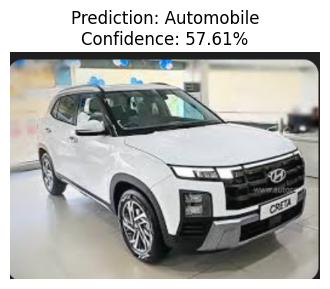

In [ ]:
from tensorflow.keras.preprocessing import image
path = "/content/car.png"
img = image.load_img(path, target_size=(32, 32))

# Convert image to numpy array and normalize (0-1 range)
x = image.img_to_array(img)
x = x / 255.0
x = np.expand_dims(x, axis=0)

class_names = ['Automobile', 'Ship', 'Truck']

# Get the raw probabilities
predictions = model.predict(x)

# Find the index with the highest probability
score = tf.nn.softmax(predictions[0])
predicted_class_index = np.argmax(predictions[0])
predicted_label = class_names[predicted_class_index]
confidence = 100 * np.max(score)

# --- DISPLAY RESULTS ---
img_display = image.load_img(path)

plt.figure(figsize=(4, 4))
plt.imshow(img_display)
plt.axis('off')
plt.title(f"Prediction: {predicted_label}\nConfidence: {confidence:.2f}%")
plt.show()